<a href="https://colab.research.google.com/github/saathvikMD/dqn/blob/main/pacman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install box2d-py
!pip install gym[Box_2D]
!pip install gym pyvirtualdisplay > /dev/null 2>&1
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
!apt-get update > /dev/null 2>&1
!apt-get install cmake > /dev/null 2>&1
!pip install --upgrade setuptools 2>&1
!pip install ez_setup > /dev/null 2>&1
!pip install gym[atari] > /dev/null 2>&1

     |████████████████████████████████| 2.0MB 4.3MB/s 
ERROR: datascience 0.10.6 has requirement folium==0.2.1, but you'll have folium 0.8.3 which is incompatible.
  Found existing installation: setuptools 51.0.0
    Uninstalling setuptools-51.0.0:
      Successfully uninstalled setuptools-51.0.0


In [ ]:
import gym
from gym import logger as gymlogger
from gym.wrappers import Monitor
gymlogger.set_level(40) #error only
import tensorflow as tf
import numpy as np
import random
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import math
import glob
import io
import base64
from IPython.display import HTML

from IPython import display as ipythondisplay
from pyvirtualdisplay import Display
display = Display(visible=0, size=(1400, 900))
display.start()

In [ ]:
"""
Utility functions to enable video recording of gym environment and displaying it
To enable video, just do "env = wrap_env(env)""
"""

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data='''<video alt="test" autoplay 
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
  else: 
    print("Could not find video")
    

def wrap_env(env):
  env = Monitor(env, './Paccman_video', video_callable=lambda episode_id: episode_id%1==0, force=True)
  return env

In [ ]:
env = wrap_env(gym.make("MsPacman-v0"))

In [ ]:
env.unwrapped.get_action_meanings()

['NOOP',
 'UP',
 'RIGHT',
 'LEFT',
 'DOWN',
 'UPRIGHT',
 'UPLEFT',
 'DOWNRIGHT',
 'DOWNLEFT']

In [ ]:
for i in range(1):
  observation = env.reset()
  total_reward = 0
  while True:
    env.render()
    
    #your agent goes here
    action = env.action_space.sample() 
         
    observation, reward, done, info = env.step(action) 
    total_reward += reward
   
        
    if done: 
      print(total_reward)
      break;
    

250.0


Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_4 (Dense)              (None, 128)               16512     
_________________________________________________________________
dense_5 (Dense)              (None, 128)               16512     
_________________________________________________________________
dense_6 (Dense)              (None, 128)               16512     
_________________________________________________________________
dense_7 (Dense)              (None, 9)                 1161      
Total params: 50,697
Trainable params: 50,697
Non-trainable params: 0
_________________________________________________________________
episode: 0   score: 310.0   memory length: 645   epsilon: 0.5244932528672183
episode: 1   score: 350.0   memory length: 1219   epsilon: 0.2953453567182228
episode: 2   score: 370.0   memory length: 1976   epsilon: 0.1384856374905753
episode: 3   sc

KeyboardInterrupt: ignored

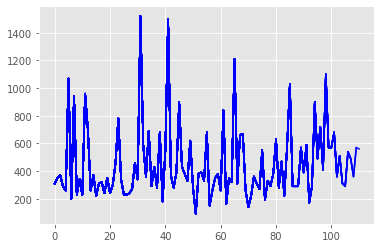

In [ ]:
import gym
from matplotlib import pylab
import random
import numpy as np
from collections import deque
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

EPISODES   = 1500
load_model = False

class Agent:
    def __init__(self, state_size, action_size):
        if load_model:
            self.state_size = state_size #Get size of the state
            self.action_size = action_size #Get size of the action

            #Hyperparameters
            self.discount_factor = 0.99 #Disocunt Factor
            self.learning_rate = 0.000001 #Learning Rate

            #Hyperparameters to adjust the Exploitation-Explore tradeoff
            self.epsilon = 0.2 #Setting the epislon (0= Explore, 1= Exploit)
            self.epsilon_decay = 0.999999 #Adjusting how our epsilon will decay
            self.epsilon_min = 0.2 #Min Epsilon

            self.batch_size = 64 #Batch Size for training the neural network
            self.train_start = 1000 #If Agent's memory is less, no training is done

        else:
            self.state_size = state_size #Get size of the state
            self.action_size = action_size #Get size of the action

            #Hyperparameters
            self.discount_factor = 0.99 #Disocunt Factor
            self.learning_rate = 0.001 #Learning Rate

            #Hyperparameters to adjust the Exploitation-Explore tradeoff
            self.epsilon = 1.0 #Setting the epislon (0= Explore, 1= Exploit)
            self.epsilon_decay = 0.999 #Adjusting how our epsilon will decay
            self.epsilon_min = 0.1 #Min Epsilon

            self.batch_size = 64 #Batch Size for training the neural network
            self.train_start = 1000 #If Agent's memory is less, no training is done

        # create main replay memory for the agent using deque
        self.memory = deque(maxlen=2000)

        # create main model
        self.model = self.build_model()

        #Loading weights if load_model=True
        if load_model:
            self.model.load_weights("./pacman.h5")

    # approximate Q function using Neural Network
    def build_model(self):
        model = Sequential()
        model.add(Dense(128, input_dim=self.state_size, activation='relu'))#State is input
        model.add(Dense(128, activation='relu'))
        model.add(Dense(128, activation='relu'))
        model.add(Dense(self.action_size, activation='linear'))#Q_Value of each action is Output
        model.summary()
        model.compile(loss='mse', optimizer=Adam(lr=self.learning_rate))
        return model

    # get action from model using epsilon-greedy policy
    def get_action(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        else:
            q_value = self.model.predict(state)
            return np.argmax(q_value[0])

    # save sample <state,action,reward,nest_state> to the replay memory
    def append_sample(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


    def train_model(self):
        if len(self.memory) < self.train_start:
            return
        batch_size = min(self.batch_size, len(self.memory))
        mini_batch = random.sample(self.memory, batch_size)

        update_input = np.zeros((batch_size, self.state_size))
        update_target = np.zeros((batch_size, self.state_size))
        action, reward, done = [], [], []

        for i in range(self.batch_size):
            update_input[i] = mini_batch[i][0]
            action.append(mini_batch[i][1])
            reward.append(mini_batch[i][2])
            update_target[i] = mini_batch[i][3]
            done.append(mini_batch[i][4])

        target = self.model.predict(update_input)
        target_val = self.model.predict(update_target)

        for i in range(self.batch_size):
            update_input[i] = mini_batch[i][0]
            action.append(mini_batch[i][1])
            reward.append(mini_batch[i][2])
            update_target[i] = mini_batch[i][3]
            done.append(mini_batch[i][4])

        target = self.model.predict(update_input)
        target_val = self.model.predict(update_target)


        for i in range(self.batch_size):
            # Q Learning: get maximum Q value at s' from model
            if done[i]:
                target[i][action[i]] = reward[i]
            else:
                target[i][action[i]] = reward[i] + self.discount_factor * (
                    np.amax(target_val[i]))

        # and do the model fit!
        self.model.fit(update_input, target, batch_size=self.batch_size,
                       epochs=1, verbose=0)



if __name__ == '__main__':
    env = wrap_env(gym.make('MsPacman-ram-v0'))
    env.reset()



    # get size of state and action from environment
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    agent = Agent(state_size, action_size)

    scores, episodes = [], []

    for e in range(EPISODES):
        done = False
        score = 0
        state = env.reset()
        state = np.reshape(state, [1, state_size])
        lives = 3
        while not done:
            dead = False
            while not dead:
                env.render()
                # get action for the current state and go one step in environment
                action = agent.get_action(state)
                next_state, reward, done, info = env.step(action)
                next_state = np.reshape(next_state, [1, state_size])
                # save the sample <s, a, r, s'> to the replay memory
                agent.append_sample(state, action, reward, next_state, done)
                # every time step do the training
                agent.train_model()

                state = next_state
                score += reward
                dead = info['ale.lives']<lives
                lives = info['ale.lives']
                # When Pacman dies gives penalty of -100
                reward = reward if not dead else -100
            if done:
                scores.append(score)
                episodes.append(e)
                pylab.plot(episodes, scores, 'b')
                pylab.savefig( "pacmanTest.png")
                print("episode:", e, "  score:", score, "  memory length:",
                         len(agent.memory), "  epsilon:", agent.epsilon)
        if (e % 50 == 0) & (load_model==False):
            agent.model.save_weights("pacman.h5")